In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [5]:
df.shape


(1340, 10)

In [6]:
pd.set_option("display.float_format", "{:.2f}".format)


In [7]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(1332, 10)

In [12]:
df.isna().sum().sum()

np.int64(0)

In [13]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


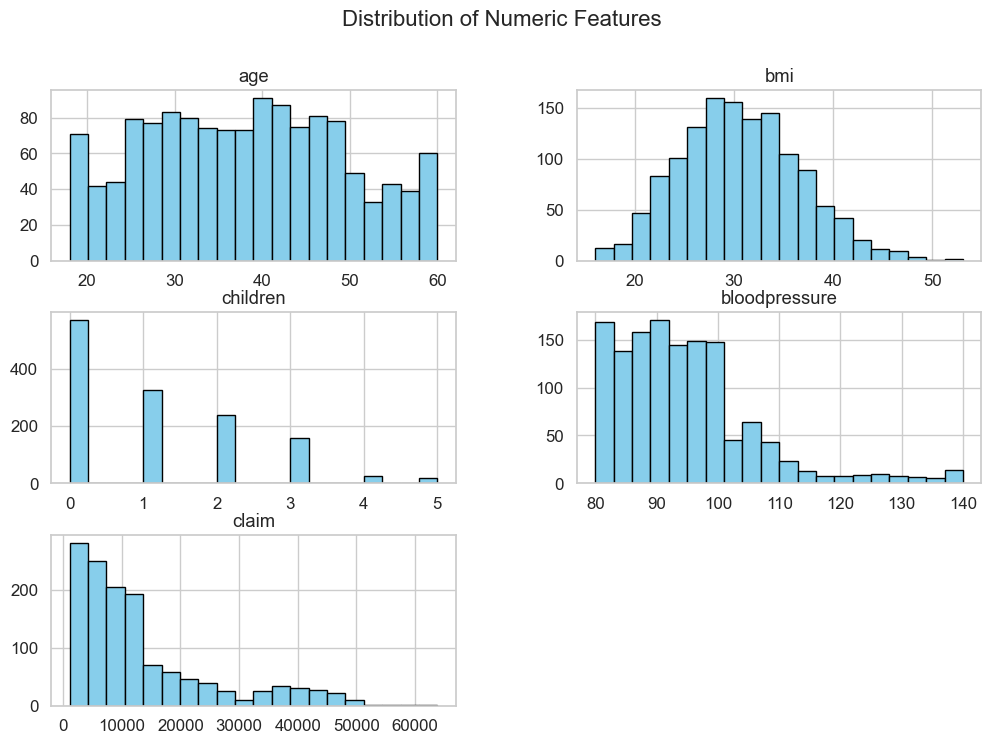

In [14]:
numeric_cols=["age", "bmi", "children", "bloodpressure","claim"]
df[numeric_cols].hist(bins=20, figsize=(12, 8), color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_21992\2651033343.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="muted")
C:\Users\DELL\AppData\Local\Temp\ipykernel_21992\2651033343.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="muted")
C:\Users\DELL\AppData\Local\Temp\ipykernel_21992\2651033343.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="muted")
C:\Users\DELL\AppData\Local\Temp\ipykernel_21992\2651033343.py:5: FutureWarning: 

Passing `palette` witho

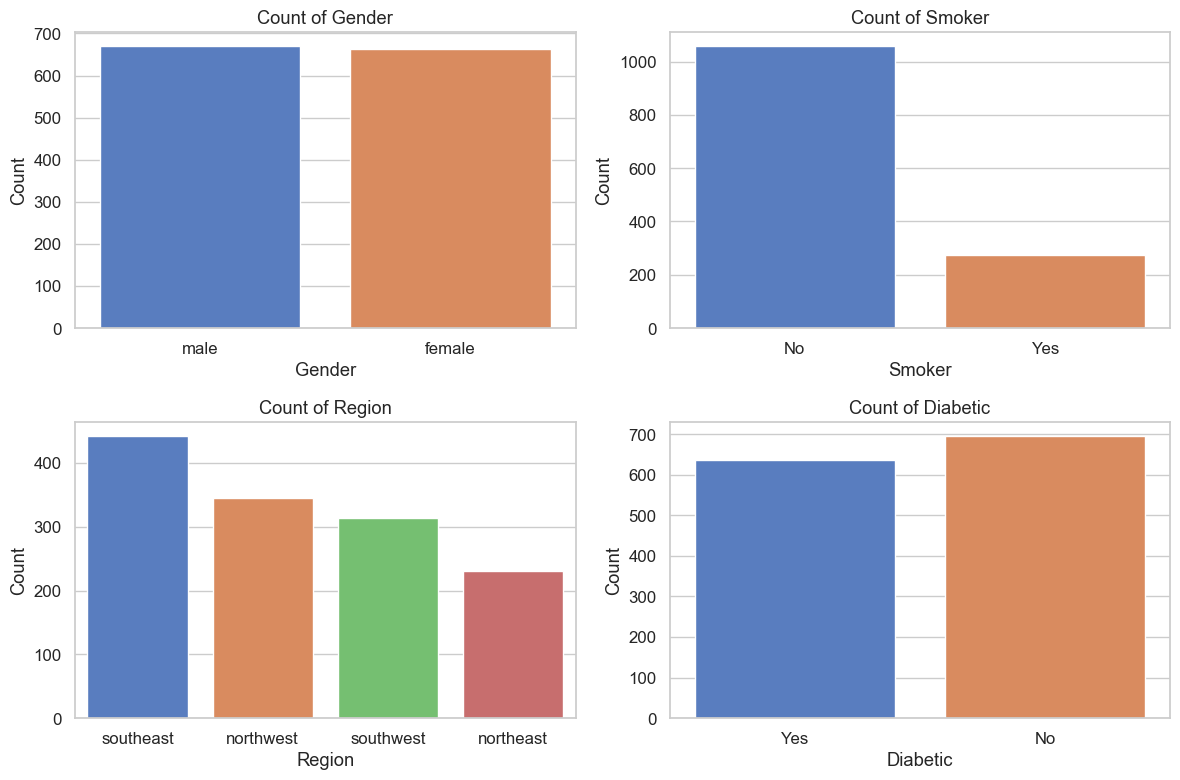

In [15]:
cat_cols=["gender", "smoker", "region","diabetic"]
plt.figure(figsize=(12, 8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col, palette="muted")
    plt.title(f"Count of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [16]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

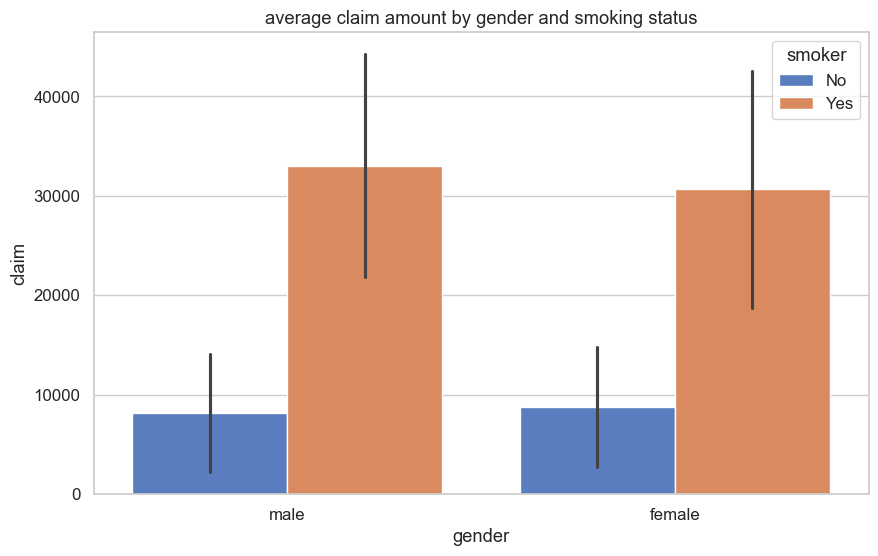

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="gender", y="claim",hue="smoker", estimator="mean", errorbar="sd")
plt.title("average claim amount by gender and smoking status")
plt.show()

In [18]:
pivot_region_diabetic= df.groupby(["region", "diabetic"])["claim"].mean().unstack()

In [19]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


Text(0.5, 1.0, 'Average Claim Amount by Region and Diabetes Status')

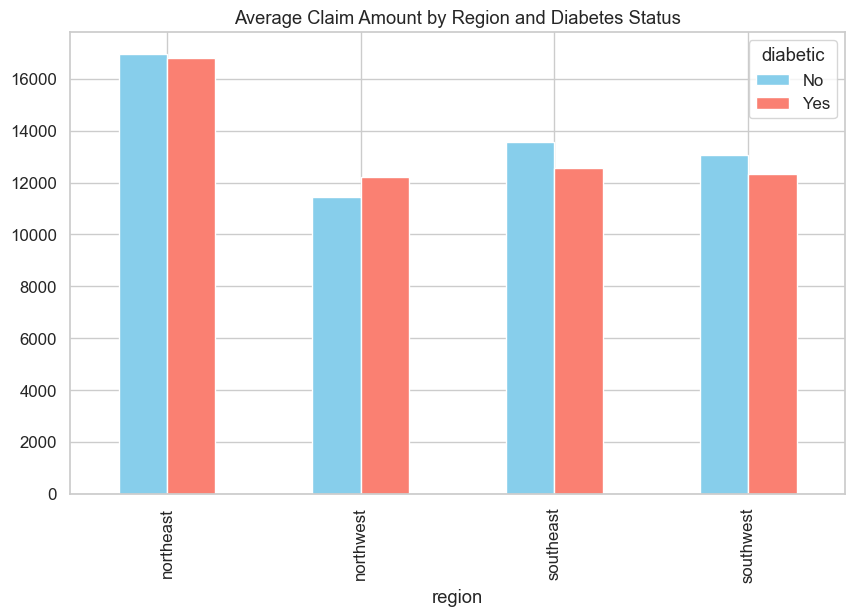

In [20]:
pivot_region_diabetic.plot(kind="bar", figsize=(10, 6), color=["skyblue", "salmon"])
plt.title("Average Claim Amount by Region and Diabetes Status")

In [21]:
pivot_table=pd.pivot_table(df,values="claim", index="region", columns="smoker", aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [22]:
pivot_table=pd.pivot_table(df,values="claim", index="children", columns="diabetic", aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [23]:
numeric_cols

['age', 'bmi', 'children', 'bloodpressure', 'claim']

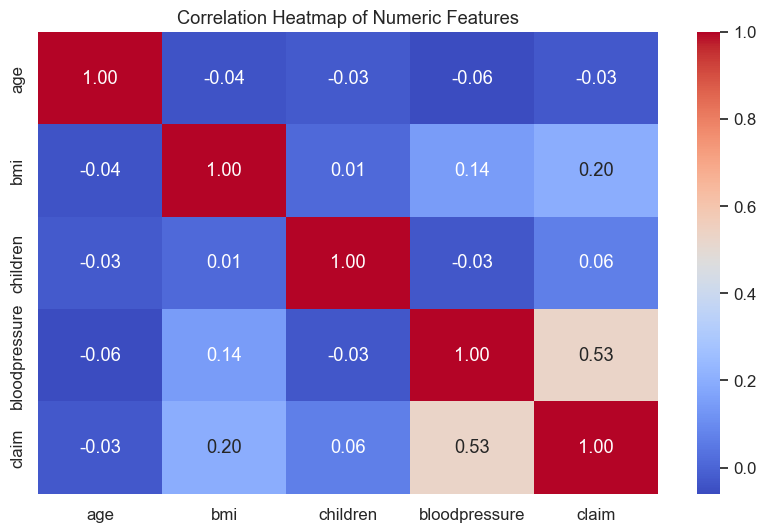

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

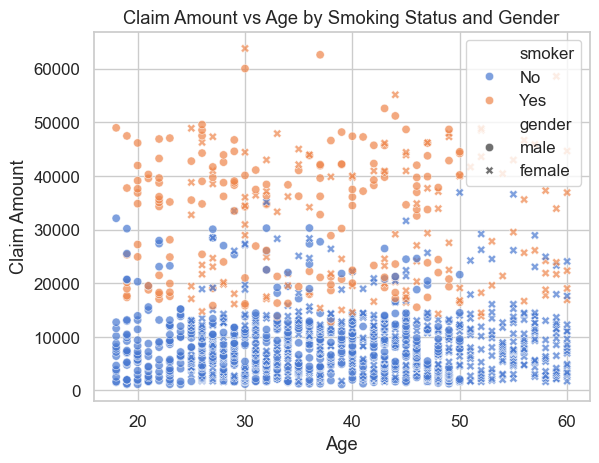

In [25]:
sns.scatterplot(data=df, x="age", y="claim", hue="smoker", style="gender",alpha=0.7)
plt.title("Claim Amount vs Age by Smoking Status and Gender")
plt.xlabel("Age")
plt.ylabel("Claim Amount")  
plt.show()

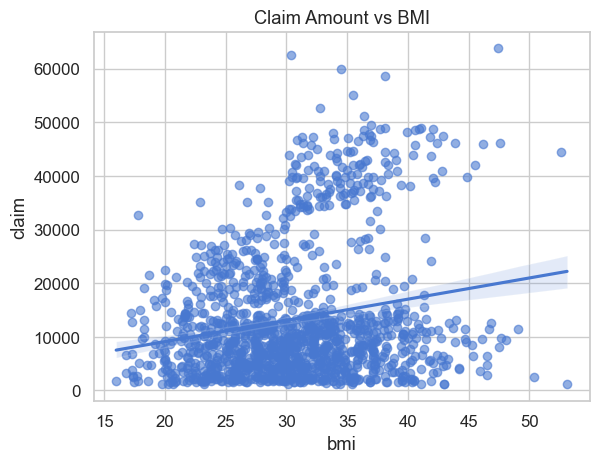

In [26]:
sns.regplot(data=df, x="bmi", y="claim", scatter_kws={"alpha": 0.6})
plt.title("Claim Amount vs BMI")
plt.show()

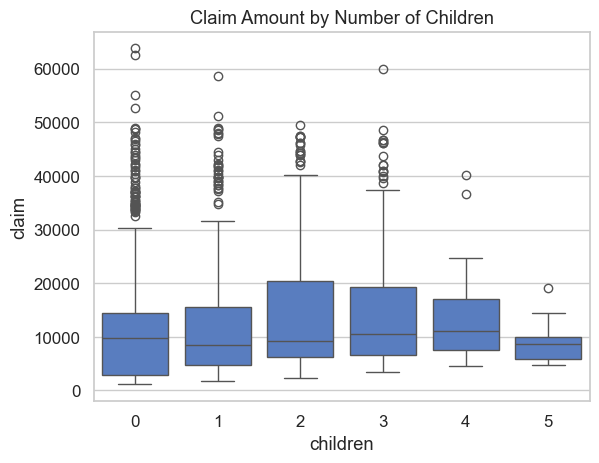

In [27]:
sns.boxplot(data=df, x="children", y="claim")
plt.title("Claim Amount by Number of Children")
plt.show()

In [28]:
df["age_group"]=pd.cut(df["age"], bins=[0, 18, 30, 45, 60, 100], labels=["<18", "18-30", "31-45", "46-60", "60+"])

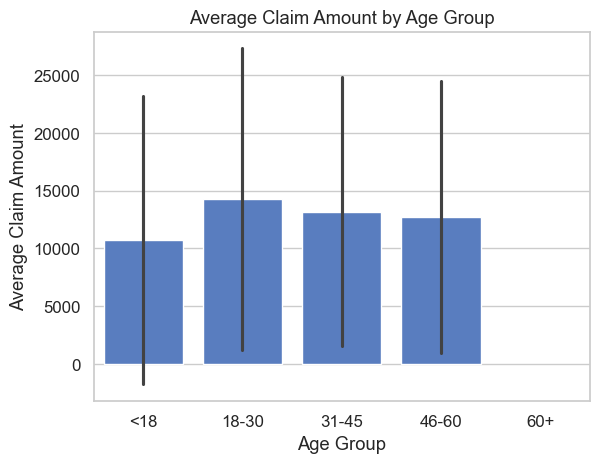

In [29]:
sns.barplot(data=df, x="age_group", y="claim", estimator="mean", errorbar="sd")
plt.title("Average Claim Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Claim Amount")
plt.show()

In [30]:
df["bmi_category"]=pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels=["Underweight", "Normal", "Overweight", "Obese"])  

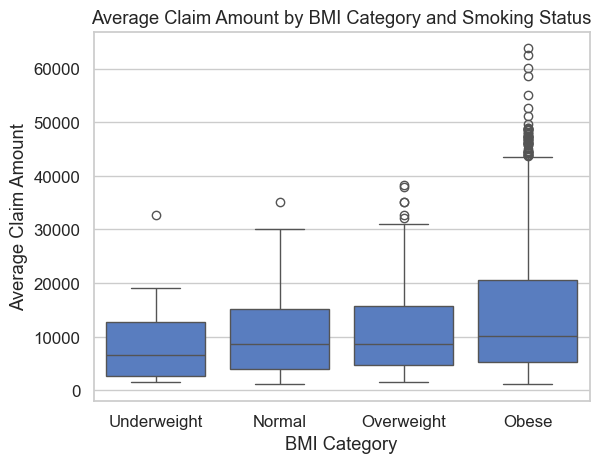

In [31]:
sns.boxplot(data=df, x="bmi_category", y="claim")
plt.title("Average Claim Amount by BMI Category and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Average Claim Amount")
plt.show()

In [32]:
region_stats= df.groupby("region").agg(
    smoker_rate=("smoker", lambda x: (x=="yes").mean()*100),
    mean_claim=("claim", "mean")
).reset_index()

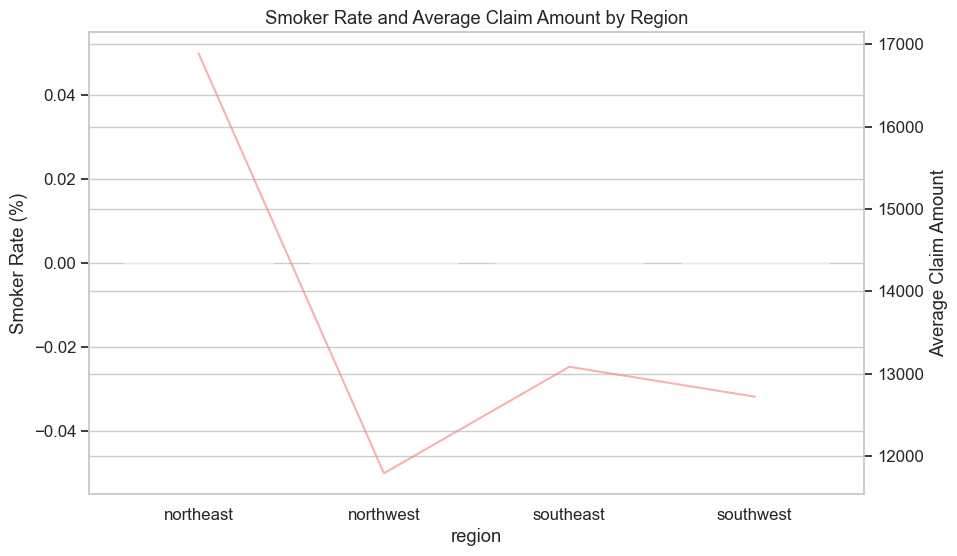

In [33]:
fig,ax1 =plt.subplots(figsize=(10, 6))
sns.barplot(data=region_stats, x="region", y="smoker_rate", ax=ax1,alpha=0.6)
ax2=ax1.twinx()
sns.lineplot(data=region_stats, x="region", y="mean_claim", ax=ax2, color="lightcoral",alpha=0.6)
ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claim Amount")
plt.title("Smoker Rate and Average Claim Amount by Region")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib


In [36]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [37]:
x= df[["age", "bmi", "children", "bloodpressure", "smoker",  "diabetic","gender"]]
y=df["claim"]


In [ ]:
cat_cols=["gender", "smoker", "diabetic"]
LabelEncoders={}

In [89]:
for col in cat_cols:
    le=LabelEncoder()
    x[col]=le.fit_transform(x[col])
    LabelEncoders[col]=le

joblib.dump(LabelEncoders, "label_encoders.pkl")

C:\Users\DELL\AppData\Local\Temp\ipykernel_21992\1198560600.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col]=le.fit_transform(x[col])
C:\Users\DELL\AppData\Local\Temp\ipykernel_21992\1198560600.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col]=le.fit_transform(x[col])
C:\Users\DELL\AppData\Local\Temp\ipykernel_21992\1198560600.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

['label_encoders.pkl']

In [90]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [91]:
num_cols = ["age", "bmi", "children", "bloodpressure"]
scaler = StandardScaler()

In [92]:
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [93]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [94]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1065, 7) (1065,)
(267, 7) (267,)


In [95]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from xgboost import XGBRegressor



In [96]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    
    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Train Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    # Test Metrics
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    return {
        "train_r2": train_r2,
        "train_mae": train_mae,
        "train_rmse": train_rmse,
        "test_r2": test_r2,
        "test_mae": test_mae,
        "test_rmse": test_rmse
    }

In [97]:
results = {}


In [98]:
lr = LinearRegression()
lr.fit(x_train, y_train)
results["Linear Regression"] = evaluate_model(lr,x_train, x_test,y_train, y_test)
print("liner regression model trained")

best_poly_model = None
best_poly_score=-np.inf

for degree in [2,3]:
    poly = PolynomialFeatures(degree=degree)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)
    poly_lr =LinearRegression()
    poly_lr.fit(x_train_poly, y_train)

    score =poly_lr.score(x_test_poly, y_test)
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model
results[f"Polynomial Regression (degree={degree})"] = evaluate_model(poly_lr,poly.fit_transform(x_train), poly.transform(x_test),y_train, y_test)
print("polynomial regression model trained")

rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200], 
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
rf_grid = GridSearchCV(rf, rf_params, cv=3, n_jobs=-1, verbose=0,scoring="r2")
rf_grid.fit(x_train, y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf,x_train, x_test,y_train, y_test)

print("random forest model trained", rf_grid.best_params_)

svr= SVR()
svr_params = {
    "kernel": ["rbf","poly", "linear"],
    "C":[1,10,50],
    "epsilon":[0.1,0.2,0.5],
    "degree":[2,3]
}

svr_grid = GridSearchCV(svr, svr_params, cv=3, n_jobs=-1, verbose=0,scoring="r2")
svr_grid.fit(x_train, y_train)
best_svr = svr_grid.best_estimator_
results["SVR"] = evaluate_model(best_svr,x_train, x_test,y_train, y_test)
print("SVR model trained", svr_grid.best_params_)

xgb = XGBRegressor(objective="reg:squarederror")

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01,0.05, 0.1],
    "subsample": [0.8, 1]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, n_jobs=-1, verbose=0,scoring="r2")
xgb_grid.fit(x_train, y_train) 
best_xgb = xgb_grid.best_estimator_
results["XGBoost"] = evaluate_model(best_xgb,x_train, x_test,y_train, y_test)   
print("XGBoost model trained", xgb_grid.best_params_)




liner regression model trained
polynomial regression model trained
random forest model trained {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
SVR model trained {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost model trained {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [107]:
results

{'Linear Regression': {'train_r2': 0.712702928452027,
  'train_mae': 4982.376040969487,
  'train_rmse': np.float64(6553.560295279058),
  'test_r2': 0.6429314836343191,
  'test_mae': 5094.126099596209,
  'test_rmse': np.float64(6934.945053902119)},
 'Polynomial Regression (degree=2)': {'train_r2': 0.7938581703472775,
  'train_mae': 4183.462253262278,
  'train_rmse': np.float64(5551.300833544412),
  'test_r2': 0.7206207534906899,
  'test_mae': 4414.880529500933,
  'test_rmse': np.float64(6134.290173855469)},
 'Random Forest': {'train_r2': 0.9068864119613761,
  'train_mae': 2746.9154434697643,
  'train_rmse': np.float64(3730.9397079904193),
  'test_r2': 0.7716268032903084,
  'test_mae': 3947.79656672095,
  'test_rmse': np.float64(5546.127003703862)},
 'SVR': {'train_r2': 0.5269140076609946,
  'train_mae': 5735.95819149686,
  'train_rmse': np.float64(8409.724030676498),
  'test_r2': 0.4711858069011813,
  'test_mae': 5640.405280832804,
  'test_rmse': np.float64(8439.540398176407)},
 'XGBoos

In [100]:
results_df = pd.DataFrame(results).T.sort_values(by="test_r2", ascending=False)

In [101]:
results_df

,train_r2,train_mae,train_rmse,test_r2,test_mae,test_rmse
Random Forest,0.91,2746.92,3730.94,0.77,3947.80,5546.13
XGBoost,0.84,3611.17,4822.33,0.77,4041.65,5568.62
Polynomial Regression (degree=2),0.79,4183.46,5551.30,0.72,4414.88,6134.29
Linear Regression,0.71,4982.38,6553.56,0.64,5094.13,6934.95
SVR,0.53,5735.96,8409.72,0.47,5640.41,8439.54


In [102]:
models ={
    "Linear Regression" : lr,
    "polynomial regression": poly_lr,
    "Random Forest": best_rf,
    "SVR":best_svr,
    "XGBoost": best_xgb
}

In [103]:
best_r2= results_df["test_r2"].max()
best_r2

np.float64(0.7716268032903084)

In [104]:
top_model_name = results_df[results_df["test_r2"]== best_r2]
top_model_name


,train_r2,train_mae,train_rmse,test_r2,test_mae,test_rmse
Random Forest,0.91,2746.92,3730.94,0.77,3947.80,5546.13


In [105]:
best_model = models[top_model_name.index[0]]
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [106]:
joblib.dump(best_model, "best_model.pkl")
print(f"best model selected: {top_model_name.index[0]}")

best model selected: Random Forest
